# COVID-19 Pakistan: Daily New Case Forecasting

Regression task on the 2020 Pakistan COVID-19 case dataset. The data is reported
per region per day; it is aggregated to a national daily time series and used to
forecast next-available daily new case counts from lagged and rolling statistics.

Pipeline: data cleaning, aggregation, leakage-safe feature engineering, model training,
evaluation, and comparison across five regression models including a stacking ensemble.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style("whitegrid")
os.makedirs("plots", exist_ok=True)

RANDOM_STATE = 42

## 1. Load Data

In [2]:
df = pd.read_csv("data/covid-19-cases-in-pakistan-2020.csv")
df = df.drop(columns=["Unnamed: 0"])
print(df.shape)
df.head()

(643, 11)


,Cumulative,Cumulative Test positive,Cumulative tests performed,Date,Discharged,Expired,Home Quarantine,New (last 24 hrs),Region,Still admitted,Tests performed in last 24 hours
0,48,2,80,3/11/2020,0,0,NaN,3,ICT,2,8
1,61,0,95,3/11/2020,0,0,NaN,6,Punjab,0,7
2,84,14,171,3/11/2020,1,0,NaN,1,Sindh,13,55
3,20,0,28,3/11/2020,0,0,NaN,0,KP,0,2
4,3,0,0,3/11/2020,0,0,NaN,0,KPTD,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Cumulative                         643 non-null    int64  
 1   Cumulative  Test positive          643 non-null    int64  
 2   Cumulative  tests performed        643 non-null    int64  
 3   Date                               643 non-null    str    
 4   Discharged                         643 non-null    int64  
 5   Expired                            643 non-null    int64  
 6   Home Quarantine                    504 non-null    float64
 7   New  (last 24 hrs)                 643 non-null    int64  
 8   Region                             643 non-null    str    
 9   Still admitted                     643 non-null    int64  
 10  Tests  performed in last 24 hours  643 non-null    str    
dtypes: float64(1), int64(7), str(3)
memory usage: 55.4 KB


## 2. Data Cleaning

Two issues in the raw data:
- `Date` is stored in two different formats (`M/D/YYYY` and `DD-Mon-YYYY`).
- `Tests  performed in last 24 hours` is stored as text and contains at least
  one non-numeric entry (`"No 0"`).

In [4]:
def parse_date(value):
    for fmt in ("%m/%d/%Y", "%d-%b-%Y"):
        try:
            return pd.to_datetime(value, format=fmt)
        except ValueError:
            continue
    return pd.NaT

df["Date"] = df["Date"].apply(parse_date)
assert df["Date"].isna().sum() == 0

In [5]:
df["Tests  performed in last 24 hours"] = (
    df["Tests  performed in last 24 hours"].astype(str).str.extract(r"(\d+)")[0]
)
df["Tests  performed in last 24 hours"] = pd.to_numeric(
    df["Tests  performed in last 24 hours"], errors="coerce"
).fillna(0)

df["Home Quarantine"] = df["Home Quarantine"].fillna(0)

In [6]:
df = df.rename(columns={
    "Cumulative": "cumulative_cases",
    "Cumulative  Test positive": "cumulative_test_positive",
    "Cumulative  tests performed": "cumulative_tests",
    "Discharged": "discharged",
    "Expired": "expired",
    "Home Quarantine": "home_quarantine",
    "New  (last 24 hrs)": "new_cases",
    "Still admitted": "still_admitted",
    "Tests  performed in last 24 hours": "tests_last24h",
    "Region": "region",
    "Date": "date",
})
df.isna().sum()

cumulative_cases            0
cumulative_test_positive    0
cumulative_tests            0
date                        0
discharged                  0
expired                     0
home_quarantine             0
new_cases                   0
region                      0
still_admitted              0
tests_last24h               0
dtype: int64

## 3. Aggregate to a National Daily Time Series

The dataset reports figures per region. Summing across regions for each date
produces a single national daily series, which is the level at which the
forecasting task is framed.

In [7]:
national = (
    df.groupby("date")
    .agg(
        new_cases=("new_cases", "sum"),
        cumulative_cases=("cumulative_cases", "sum"),
        cumulative_test_positive=("cumulative_test_positive", "sum"),
        cumulative_tests=("cumulative_tests", "sum"),
        discharged=("discharged", "sum"),
        expired=("expired", "sum"),
        home_quarantine=("home_quarantine", "sum"),
        still_admitted=("still_admitted", "sum"),
        tests_last24h=("tests_last24h", "sum"),
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)
print(national.shape)
national.head()

(90, 10)


,date,new_cases,cumulative_cases,cumulative_test_positive,cumulative_tests,discharged,expired,home_quarantine,still_admitted,tests_last24h
0,2020-03-11,14,248,19,422,1,0,0.0,18,80
1,2020-03-12,23,271,20,471,2,0,0.0,18,53
2,2020-03-13,47,318,21,531,2,0,0.0,19,60
3,2020-03-14,45,363,28,609,3,0,0.0,25,78
4,2020-03-15,19,382,31,686,3,0,0.0,28,77


## 4. Exploratory Data Analysis

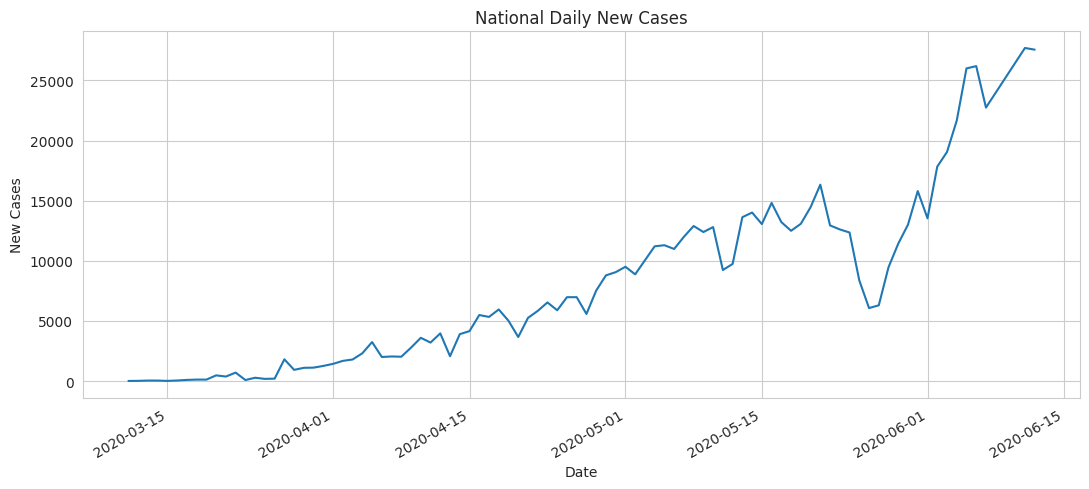

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national["date"], national["new_cases"], color="#1f77b4")
ax.set_title("National Daily New Cases")
ax.set_xlabel("Date")
ax.set_ylabel("New Cases")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("plots/daily_new_cases.png", dpi=150)
plt.show()

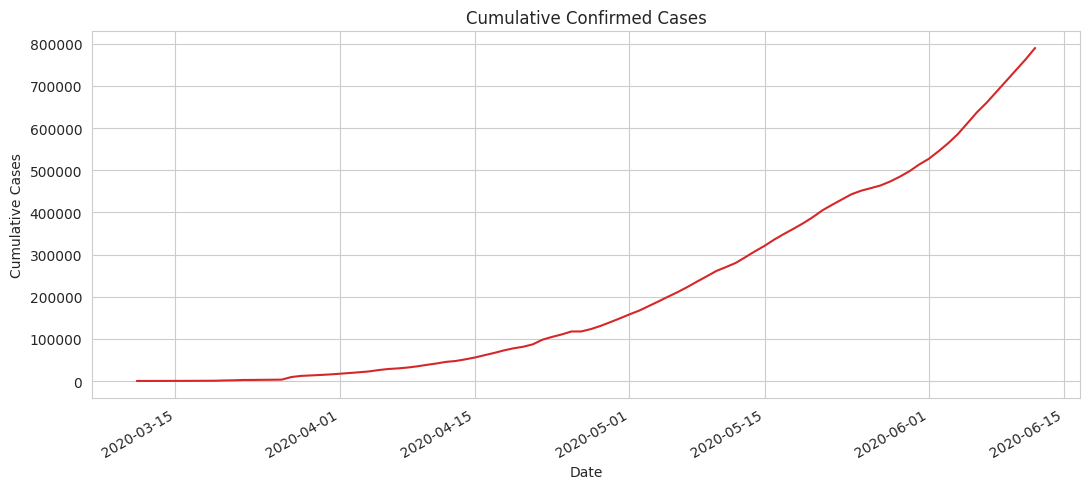

In [9]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national["date"], national["cumulative_cases"], color="#d62728")
ax.set_title("Cumulative Confirmed Cases")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Cases")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("plots/cumulative_cases.png", dpi=150)
plt.show()

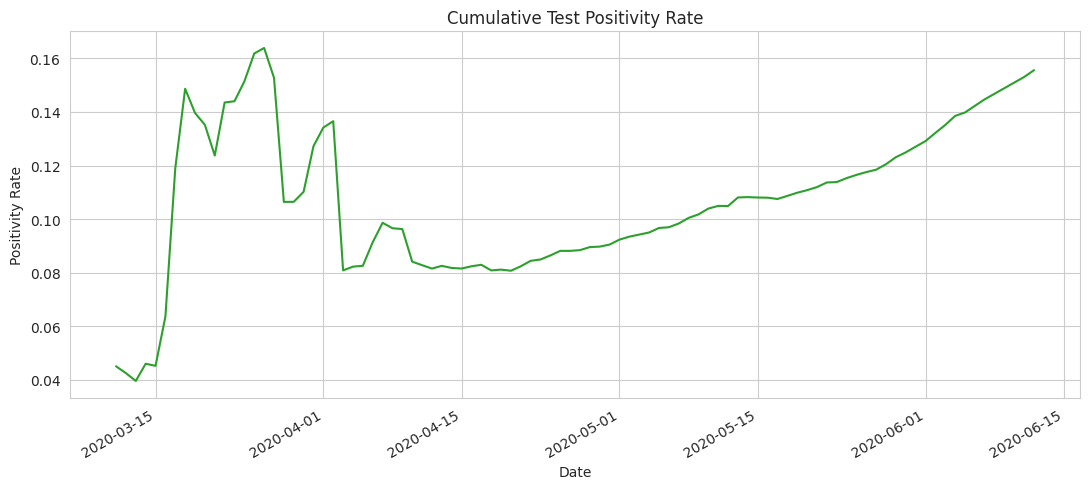

In [10]:
positivity = national["cumulative_test_positive"] / national["cumulative_tests"].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national["date"], positivity, color="#2ca02c")
ax.set_title("Cumulative Test Positivity Rate")
ax.set_xlabel("Date")
ax.set_ylabel("Positivity Rate")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("plots/positivity_rate.png", dpi=150)
plt.show()

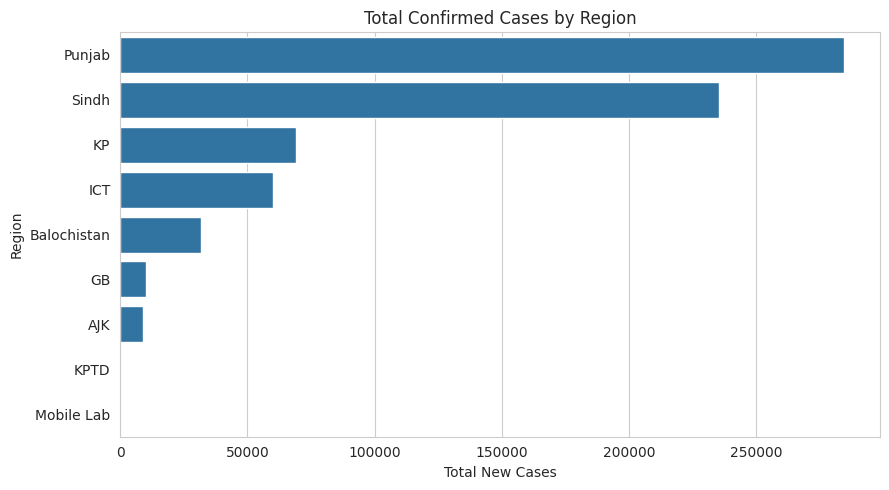

In [11]:
region_totals = df.groupby("region")["new_cases"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=region_totals.values, y=region_totals.index, ax=ax, color="#1f77b4")
ax.set_title("Total Confirmed Cases by Region")
ax.set_xlabel("Total New Cases")
ax.set_ylabel("Region")
fig.tight_layout()
fig.savefig("plots/cases_by_region.png", dpi=150)
plt.show()

## 5. Feature Engineering

Forecasting features must only use information available up to and including
the previous day. Lagged case counts, rolling statistics shifted by one day,
calendar position, and lagged testing volume already satisfy that. The test
positivity rate does not by default: `cumulative_test_positive` and
`cumulative_tests` on day t already include day t's own confirmed cases and
tests, so a same-day positivity rate is partly a function of the value being
predicted. It is lagged by one day here, exactly like every other feature.

In [12]:
national["positivity_rate"] = (
    national["cumulative_test_positive"] / national["cumulative_tests"].replace(0, np.nan)
).fillna(0)
national["positivity_rate_lag1"] = national["positivity_rate"].shift(1).fillna(0)

national["day_of_week"] = national["date"].dt.dayofweek
national["days_since_start"] = (national["date"] - national["date"].min()).dt.days

for lag in [1, 2, 3, 7]:
    national[f"new_cases_lag{lag}"] = national["new_cases"].shift(lag)

national["new_cases_roll_mean3"] = national["new_cases"].shift(1).rolling(3).mean()
national["new_cases_roll_mean7"] = national["new_cases"].shift(1).rolling(7).mean()
national["new_cases_roll_std7"] = national["new_cases"].shift(1).rolling(7).std()

national["tests_last24h_lag1"] = national["tests_last24h"].shift(1)

national["growth_rate"] = national["new_cases"].pct_change().replace([np.inf, -np.inf], np.nan)
national["growth_rate_lag1"] = national["growth_rate"].shift(1).fillna(0)

national_model = national.dropna().reset_index(drop=True)
print(national_model.shape)
national_model.head()

(83, 24)


,date,new_cases,cumulative_cases,cumulative_test_positive,cumulative_tests,discharged,expired,home_quarantine,still_admitted,tests_last24h,...,new_cases_lag1,new_cases_lag2,new_cases_lag3,new_cases_lag7,new_cases_roll_mean3,new_cases_roll_mean7,new_cases_roll_std7,tests_last24h_lag1,growth_rate,growth_rate_lag1
0,2020-03-18,127,612,241,1621,4,0,0.0,235,0,...,100.0,52.0,19.0,14.0,57.000000,42.857143,29.345236,499.0,0.270000,0.923077
1,2020-03-19,126,734,302,2163,5,2,0.0,293,0,...,127.0,100.0,52.0,23.0,93.000000,59.000000,39.979161,0.0,-0.007874,0.270000
2,2020-03-20,478,1364,461,3410,5,2,0.0,454,0,...,126.0,127.0,100.0,47.0,117.666667,73.714286,43.334799,0.0,2.793651,-0.007874
3,2020-03-21,380,1776,495,4001,5,3,0.0,487,0,...,478.0,126.0,127.0,45.0,243.666667,135.285714,156.771292,0.0,-0.205021,2.793651
4,2020-03-22,709,2574,750,5225,5,3,0.0,742,0,...,380.0,478.0,126.0,19.0,328.000000,183.142857,174.721138,0.0,0.865789,-0.205021


In [13]:
feature_cols = [
    "day_of_week",
    "days_since_start",
    "positivity_rate_lag1",
    "new_cases_lag1",
    "new_cases_lag2",
    "new_cases_lag3",
    "new_cases_lag7",
    "new_cases_roll_mean3",
    "new_cases_roll_mean7",
    "new_cases_roll_std7",
    "tests_last24h_lag1",
    "growth_rate_lag1",
]
target_col = "new_cases"

X = national_model[feature_cols]
y = national_model[target_col]
X.shape, y.shape

((83, 12), (83,))

## 6. Train / Test Split

The split is chronological (no shuffling) so the test set represents a genuine
future forecasting window relative to training data.

In [14]:
split_idx = int(len(national_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
train_dates = national_model["date"].iloc[:split_idx]
test_dates = national_model["date"].iloc[split_idx:]

print(f"Train: {X_train.shape[0]} rows ({train_dates.min().date()} to {train_dates.max().date()})")
print(f"Test:  {X_test.shape[0]} rows ({test_dates.min().date()} to {test_dates.max().date()})")

Train: 66 rows (2020-03-18 to 2020-05-23)
Test:  17 rows (2020-05-24 to 2020-06-12)


## 7. Model Training

Five models are trained: Ridge Regression, Random Forest, Gradient Boosting,
XGBoost, and a Stacking Ensemble combining all four as base learners with a
Ridge meta-learner. `TimeSeriesSplit` is used for tuning below; the stacking
ensemble itself uses standard k-fold internally since `StackingRegressor`
requires its cross-validation folds to fully partition the training data,
which `TimeSeriesSplit` does not do.

In [15]:
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ]),
    "RandomForest": RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=RANDOM_STATE
    ),
    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbosity=0,
    ),
}

trained_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test)

In [16]:
estimators = [
    ("ridge", Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])),
    ("rf", RandomForestRegressor(n_estimators=300, max_depth=6, min_samples_leaf=2, random_state=RANDOM_STATE)),
    ("gb", GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)),
    ("xgb", XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=0,
    )),
]

stacking_model = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(alpha=1.0),
    cv=5,
)
stacking_model.fit(X_train, y_train)
trained_models["StackingEnsemble"] = stacking_model
predictions["StackingEnsemble"] = stacking_model.predict(X_test)

## 8. Evaluation

In [17]:
def evaluate(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }

results = pd.DataFrame({
    name: evaluate(y_test, preds) for name, preds in predictions.items()
}).T.sort_values("RMSE")

results

,MAE,RMSE,R2
Ridge,3795.958061,4425.530057,0.628823
StackingEnsemble,5172.676516,6165.318695,0.279620
GradientBoosting,5903.939561,7654.292077,-0.110352
XGBoost,6088.378418,7758.186902,-0.140699
RandomForest,6090.155732,7764.094740,-0.142437


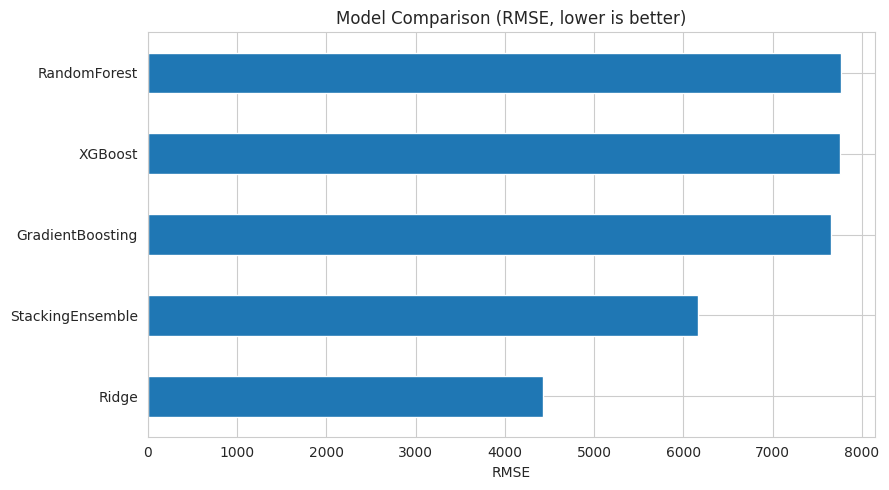

In [18]:
fig, ax = plt.subplots(figsize=(9, 5))
results["RMSE"].sort_values().plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_title("Model Comparison (RMSE, lower is better)")
ax.set_xlabel("RMSE")
fig.tight_layout()
fig.savefig("plots/model_comparison_rmse.png", dpi=150)
plt.show()

Best model: Ridge


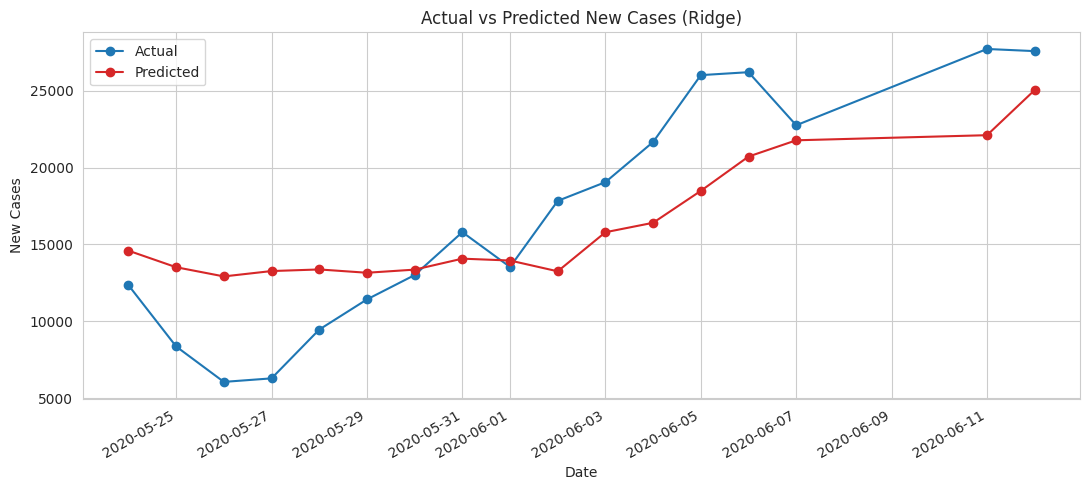

In [19]:
best_model_name = results["RMSE"].idxmin()
best_model = trained_models[best_model_name]
print(f"Best model: {best_model_name}")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_dates, y_test.values, label="Actual", marker="o", color="#1f77b4")
ax.plot(test_dates, predictions[best_model_name], label="Predicted", marker="o", color="#d62728")
ax.set_title(f"Actual vs Predicted New Cases ({best_model_name})")
ax.set_xlabel("Date")
ax.set_ylabel("New Cases")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("plots/actual_vs_predicted.png", dpi=150)
plt.show()

## 9. Feature Importance

Feature importance from the tree-based models, averaged, to see which
engineered features drive the predictions.

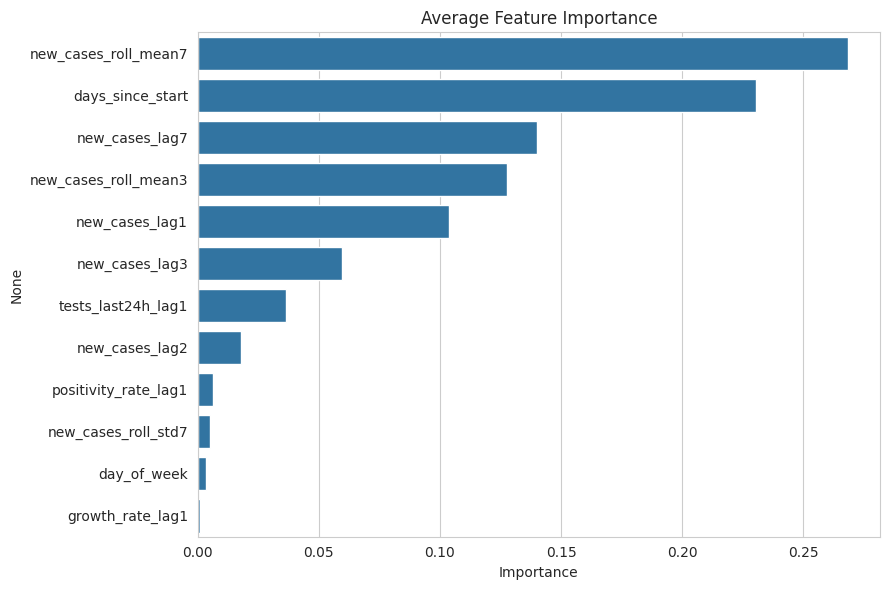

,RandomForest,GradientBoosting,XGBoost,Average
new_cases_roll_mean7,0.236391,0.165616,0.402784,0.268263
days_since_start,0.254362,0.299872,0.136965,0.230400
new_cases_lag7,0.105696,0.273204,0.041423,0.140108
new_cases_roll_mean3,0.123319,0.042088,0.217011,0.127473
new_cases_lag1,0.100337,0.147923,0.063473,0.103911
new_cases_lag3,0.066444,0.010335,0.101287,0.059355
tests_last24h_lag1,0.040877,0.041835,0.026225,0.036313
new_cases_lag2,0.052248,0.000151,0.001720,0.018040
positivity_rate_lag1,0.009744,0.004527,0.005011,0.006428
new_cases_roll_std7,0.006263,0.007025,0.002298,0.005195


In [20]:
importances = pd.DataFrame({
    "RandomForest": trained_models["RandomForest"].feature_importances_,
    "GradientBoosting": trained_models["GradientBoosting"].feature_importances_,
    "XGBoost": trained_models["XGBoost"].feature_importances_,
}, index=feature_cols)

importances["Average"] = importances.mean(axis=1)
importances = importances.sort_values("Average", ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=importances["Average"], y=importances.index, ax=ax, color="#1f77b4")
ax.set_title("Average Feature Importance")
ax.set_xlabel("Importance")
fig.tight_layout()
fig.savefig("plots/feature_importance.png", dpi=150)
plt.show()

importances

## 10. Hyperparameter Tuning (Best Model)

A small grid search over the best-performing model's key hyperparameters,
using `TimeSeriesSplit` to keep validation folds chronological.

In [21]:
param_grids = {
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 50.0]},
    "RandomForest": {"n_estimators": [200, 300, 500], "max_depth": [4, 6, 8]},
    "GradientBoosting": {"n_estimators": [200, 300, 500], "learning_rate": [0.03, 0.05, 0.1]},
    "XGBoost": {"n_estimators": [200, 300, 500], "max_depth": [3, 4, 5]},
}

if best_model_name in param_grids:
    base_estimator = models[best_model_name]
    grid = GridSearchCV(
        base_estimator,
        param_grids[best_model_name],
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )
    grid.fit(X_train, y_train)
    tuned_model = grid.best_estimator_
    tuned_preds = tuned_model.predict(X_test)
    print("Best params:", grid.best_params_)
    print("Tuned test metrics:", evaluate(y_test, tuned_preds))
else:
    tuned_model = best_model
    print("Stacking ensemble selected as best model; using it directly without further tuning.")

Best params: {'model__alpha': 10.0}
Tuned test metrics: {'MAE': 3574.1146752603754, 'RMSE': 4227.386787323974, 'R2': 0.6613161745193648}


## 11. Save Final Model

In [22]:
os.makedirs("models", exist_ok=True)
final_model = tuned_model if best_model_name in param_grids else best_model
joblib.dump(final_model, "models/final_model.joblib")
print(f"Saved final model ({best_model_name}) to models/final_model.joblib")

Saved final model (Ridge) to models/final_model.joblib
